In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Laden der Rohdaten (stündliche Messwerte Nürnberg 1980–2024)
df = pd.read_csv("../03_app/data/../data/raw/data.csv")

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df.set_index("timestamp", inplace=True)
elif "datum" in df.columns and "stunde" in df.columns:
    df["timestamp"] = pd.to_datetime(df["datum"]) + pd.to_timedelta(df["stunde"], unit="h")
    df.set_index("timestamp", inplace=True)

print(f"{len(df):,} Zeilen von {df.index.min().date()} bis {df.index.max().date()}")

394,488 Zeilen von 1980-01-01 bis 2024-12-31


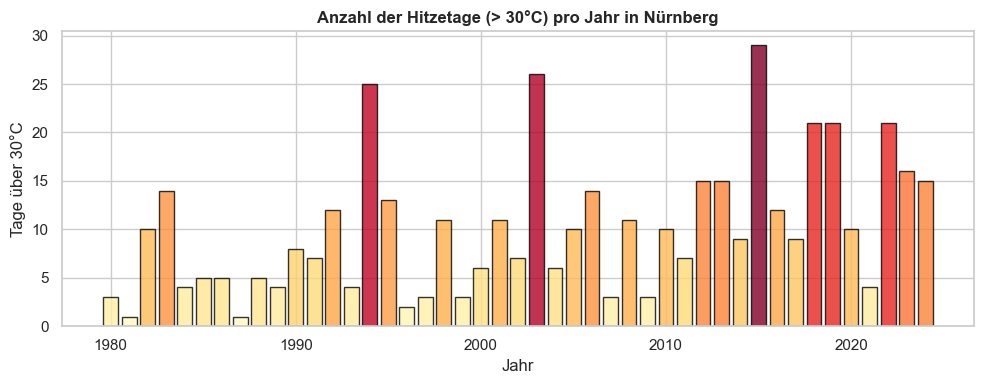

In [2]:
# Hitzetag-Definition: Tagesmaximum > 30 °C (DWD-Konvention)
df_daily_max = df["temperatur_2m"].resample("D").max()
df_hitzetage = (df_daily_max[df_daily_max > 30]
                .resample("YE").count()
                .to_frame(name="Anzahl Hitzetage"))
df_hitzetage.index = df_hitzetage.index.year

fig, ax = plt.subplots(figsize=(10, 4))
farben = sns.color_palette("YlOrRd", as_cmap=True)(
    df_hitzetage["Anzahl Hitzetage"] / df_hitzetage["Anzahl Hitzetage"].max()
)
ax.bar(df_hitzetage.index, df_hitzetage["Anzahl Hitzetage"],
       color=farben, edgecolor="black", alpha=0.8)
ax.set_title("Anzahl der Hitzetage (> 30°C) pro Jahr in Nürnberg",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Jahr")
ax.set_ylabel("Tage über 30°C")
plt.tight_layout()
plt.show()